<a href="https://colab.research.google.com/github/brugabom95/challenge_alura_store/blob/main/Alura_Store.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1. Importação dos dados

In [ ]:
# 1. Importação das Bibliotecas e Dados
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

# URLs dos arquivos
url1 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_1.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_4.csv"

# Carregamento dos dados
loja1 = pd.read_csv(url1)
loja2 = pd.read_csv(url2)
loja3 = pd.read_csv(url3)
loja4 = pd.read_csv(url4)


# 2. Funções Auxiliares de Formatação

In [ ]:
# 2. Funções Auxiliares de Formatação
def format_money_pt_br(amount):
    if not isinstance(amount, (int, float)):
        return amount
    s = f"{amount:,.2f}"
    s = s.replace(",", "X").replace(".", ",").replace("X", ".")
    return f"R$ {s}"

def unformat_money_pt_br(formatted_amount):
    if not isinstance(formatted_amount, str):
        return formatted_amount
    s = formatted_amount.replace("R$", "").replace(" ", "")
    s = s.replace(".", "").replace(",", ".")
    return float(s)


# 3. Análise do Faturamento

In [ ]:
# 3. Análise do Faturamento
# Convertendo datas (opcional para análise temporal)
for df in [loja1, loja2, loja3, loja4]:
    df['Data da Compra'] = pd.to_datetime(df['Data da Compra'], format='%d/%m/%Y')

faturamento_total_loja1 = loja1['Preço'].sum()
faturamento_total_loja2 = loja2['Preço'].sum()
faturamento_total_loja3 = loja3['Preço'].sum()
faturamento_total_loja4 = loja4['Preço'].sum()

print(f"Faturamento total da Loja 1: {format_money_pt_br(faturamento_total_loja1)}")
print(f"Faturamento total da Loja 2: {format_money_pt_br(faturamento_total_loja2)}")
print(f"Faturamento total da Loja 3: {format_money_pt_br(faturamento_total_loja3)}")
print(f"Faturamento total da Loja 4: {format_money_pt_br(faturamento_total_loja4)}")


Faturamento total da Loja 1: R$ 1.534.509,12
Faturamento total da Loja 2: R$ 1.488.459,06
Faturamento total da Loja 3: R$ 1.464.025,03
Faturamento total da Loja 4: R$ 1.384.497,58


# 4. Vendas por Categoria

In [ ]:
# 4. Vendas por Categoria
def analise_vendas_categoria(df, nome_loja):
    vendas = df.groupby('Categoria do Produto').agg(
        Total_Preco=('Preço', 'sum'),
        Quantidade=('Produto', 'size')
    ).sort_values(by='Total_Preco', ascending=False)

    total_df = pd.DataFrame([{
        'Categoria do Produto': 'Total Geral',
        'Total_Preco': vendas['Total_Preco'].sum(),
        'Quantidade': vendas['Quantidade'].sum()
    }])

    combinado = pd.concat([vendas.reset_index(), total_df], ignore_index=True)
    formatado = combinado.copy()
    formatado['Total_Preco'] = formatado['Total_Preco'].apply(format_money_pt_br)
    print(f"\nVendas por Categoria e Total Geral - {nome_loja}:")
    display(formatado)
    return vendas

vendas_por_categoria_loja1 = analise_vendas_categoria(loja1, "Loja 1")
vendas_por_categoria_loja2 = analise_vendas_categoria(loja2, "Loja 2")
vendas_por_categoria_loja3 = analise_vendas_categoria(loja3, "Loja 3")
vendas_por_categoria_loja4 = analise_vendas_categoria(loja4, "Loja 4")


Vendas por Categoria e Total Geral - Loja 1:


,Categoria do Produto,Total_Preco,Quantidade
0,eletronicos,"R$ 572.659,23",448
1,eletrodomesticos,"R$ 484.913,36",312
2,moveis,"R$ 250.178,11",465
3,instrumentos musicais,"R$ 121.731,69",182
4,esporte e lazer,"R$ 52.387,55",284
5,brinquedos,"R$ 23.993,78",324
6,utilidades domesticas,"R$ 16.931,48",171
7,livros,"R$ 11.713,92",173
8,Total Geral,"R$ 1.534.509,12",2359



Vendas por Categoria e Total Geral - Loja 2:


,Categoria do Produto,Total_Preco,Quantidade
0,eletronicos,"R$ 547.773,71",422
1,eletrodomesticos,"R$ 464.758,13",305
2,moveis,"R$ 235.234,68",442
3,instrumentos musicais,"R$ 139.987,03",224
4,esporte e lazer,"R$ 46.326,09",275
5,brinquedos,"R$ 21.262,21",313
6,utilidades domesticas,"R$ 19.662,86",181
7,livros,"R$ 13.454,35",197
8,Total Geral,"R$ 1.488.459,06",2359



Vendas por Categoria e Total Geral - Loja 3:


,Categoria do Produto,Total_Preco,Quantidade
0,eletronicos,"R$ 547.699,92",451
1,eletrodomesticos,"R$ 438.984,89",278
2,moveis,"R$ 268.095,56",499
3,instrumentos musicais,"R$ 103.174,45",177
4,esporte e lazer,"R$ 47.456,10",277
5,brinquedos,"R$ 25.869,20",315
6,utilidades domesticas,"R$ 20.080,21",177
7,livros,"R$ 12.664,70",185
8,Total Geral,"R$ 1.464.025,03",2359



Vendas por Categoria e Total Geral - Loja 4:


,Categoria do Produto,Total_Preco,Quantidade
0,eletronicos,"R$ 545.966,86",451
1,eletrodomesticos,"R$ 377.680,65",254
2,moveis,"R$ 256.705,65",480
3,instrumentos musicais,"R$ 100.136,50",170
4,esporte e lazer,"R$ 44.465,65",277
5,brinquedos,"R$ 27.015,67",338
6,utilidades domesticas,"R$ 20.098,83",201
7,livros,"R$ 12.427,77",187
8,Total Geral,"R$ 1.384.497,58",2358


# 5. Média de Avaliação

In [ ]:
# 5. Média de Avaliação
print("\nMédias de Avaliação:")
print(f"Loja 1: {loja1['Avaliação da compra'].mean():.2f}")
print(f"Loja 2: {loja2['Avaliação da compra'].mean():.2f}")
print(f"Loja 3: {loja3['Avaliação da compra'].mean():.2f}")
print(f"Loja 4: {loja4['Avaliação da compra'].mean():.2f}")


Médias de Avaliação:
Loja 1: 3.98
Loja 2: 4.04
Loja 3: 4.05
Loja 4: 4.00


# 6. Produtos Mais e Menos Vendidos

In [ ]:
# 6. Produtos Mais e Menos Vendidos
def top_produtos(df, nome_loja, top=True):
    ordem = not top
    label = "Mais" if top else "Menos"
    resultado = df.groupby('Produto').agg(
        Total_Preco=('Preço', 'sum'),
        Quantidade=('Produto', 'size')
    ).sort_values(by='Total_Preco', ascending=ordem).head(5)

    formatado = resultado.copy()
    formatado['Total_Preco'] = formatado['Total_Preco'].apply(format_money_pt_br)
    print(f"\nTop 5 Produtos {label} Vendidos - {nome_loja}:")
    display(formatado)
    return resultado

mais_vendidos_loja1 = top_produtos(loja1, "Loja 1")
mais_vendidos_loja2 = top_produtos(loja2, "Loja 2")
mais_vendidos_loja3 = top_produtos(loja3, "Loja 3")
mais_vendidos_loja4 = top_produtos(loja4, "Loja 4")

menos_vendidos_loja1 = top_produtos(loja1, "Loja 1", top=False)
menos_vendidos_loja2 = top_produtos(loja2, "Loja 2", top=False)
menos_vendidos_loja3 = top_produtos(loja3, "Loja 3", top=False)
menos_vendidos_loja4 = top_produtos(loja4, "Loja 4", top=False)


Top 5 Produtos Mais Vendidos - Loja 1:


,Total_Preco,Quantidade
Produto,,
TV Led UHD 4K,"R$ 189.534,28",60
Geladeira,"R$ 149.524,28",54
Celular Plus X42,"R$ 130.536,40",49
Smart TV,"R$ 89.936,15",44
Lavadora de roupas,"R$ 87.711,30",47



Top 5 Produtos Mais Vendidos - Loja 2:


,Total_Preco,Quantidade
Produto,,
Celular Plus X42,"R$ 150.967,83",55
TV Led UHD 4K,"R$ 137.833,06",45
Geladeira,"R$ 130.176,48",49
Lavadora de roupas,"R$ 89.016,81",49
Smart TV,"R$ 81.522,94",40



Top 5 Produtos Mais Vendidos - Loja 3:


...

,Total_Preco,Quantidade
Produto,,
Cubo mágico 8x8,"R$ 858,22",45
Dinossauro Rex,"R$ 1.027,41",42
Corda de pular,"R$ 1.142,54",50
Xadrez de madeira,"R$ 1.717,05",45
Jogo de copos,"R$ 2.056,69",46



Top 5 Produtos Menos Vendidos - Loja 3:


,Total_Preco,Quantidade
Produto,,
Cubo mágico 8x8,"R$ 853,81",44
Dinossauro Rex,"R$ 1.060,78",46
Corda de pular,"R$ 1.137,76",53
Jogo de copos,"R$ 1.614,20",36
Blocos de montar,"R$ 1.649,81",35



Top 5 Produtos Menos Vendidos - Loja 4:


,Total_Preco,Quantidade
Produto,,
Corda de pular,"R$ 939,74",43
Cubo mágico 8x8,"R$ 997,38",47
Dinossauro Rex,"R$ 1.143,94",47
Xadrez de madeira,"R$ 1.434,09",39
Jogo de copos,"R$ 1.962,24",46


# 7. Análise de Frete


In [ ]:
frete_m1, frete_m2, frete_m3, frete_m4 = loja1['Frete'].mean(), loja2['Frete'].mean(), loja3['Frete'].mean(), loja4['Frete'].mean()

comparativo_faturamento_frete = pd.DataFrame({
    'Loja': ['Loja 1', 'Loja 2', 'Loja 3', 'Loja 4'],
    'Faturamento Total': [faturamento_total_loja1, faturamento_total_loja2, faturamento_total_loja3, faturamento_total_loja4],
    'Frete Médio': [format_money_pt_br(frete_m1), format_money_pt_br(frete_m2), format_money_pt_br(frete_m3), format_money_pt_br(frete_m4)]
})
comparativo_faturamento_frete['Faturamento Total'] = comparativo_faturamento_frete['Faturamento Total'].apply(format_money_pt_br)
print("\nComparativo Faturamento vs Frete:")
display(comparativo_faturamento_frete)


Comparativo Faturamento vs Frete:


,Loja,Faturamento Total,Frete Médio
0,Loja 1,"R$ 1.534.509,12","R$ 34,69"
1,Loja 2,"R$ 1.488.459,06","R$ 33,62"
2,Loja 3,"R$ 1.464.025,03","R$ 33,07"
3,Loja 4,"R$ 1.384.497,58","R$ 31,28"


Agora que calculamos o frete médio para cada loja, vamos compará-los:

*   Loja 1: 34.69 reais
*   Loja 2: 33.62 reais
*   Loja 3: 33.07 reais
*   Loja 4: 31.28 reais

### Análise do Frete Médio:

Podemos observar que a **Loja 4** possui o menor frete médio, enquanto a **Loja 1** possui o maior. As lojas 2 e 3 apresentam valores intermediários, com a Loja 3 sendo ligeiramente menor que a Loja 2.

Essa diferença pode ser explorada para entender os fatores que influenciam o custo do frete em cada loja, como localização geográfica, parceiros de entrega ou volume de vendas.

## Análise Comparativa do Frete Médio e Faturamento Total

Comparar o frete médio de cada loja com o faturamento total, identificando possíveis relações.

### Relação entre Faturamento Total e Frete Médio:

Ao analisar o DataFrame `comparativo_faturamento_frete`:

*   **Loja 1:** Apresenta o maior faturamento total (1.534.509,12 reais) e também o maior frete médio (34.69 reais).
*   **Loja 2:** Possui o segundo maior faturamento (1.488.459,06 reais) e o segundo maior frete médio (33.62 reais).
*   **Loja 3:** Está em terceiro lugar em faturamento (1.464.025,03 reais) e em terceiro lugar em frete médio (33.07 reais).
*   **Loja 4:** Registra o menor faturamento total (1.384.497,58 reais) e o menor frete médio (31.28 reais).

**Observa-se uma correlação direta entre faturamento total e frete médio:** Lojas com maior faturamento tendem a ter um frete médio mais alto, e vice-versa. Isso pode sugerir que as lojas com maior volume de vendas (e consequentemente maior faturamento) podem estar enviando para locais mais distantes ou com mais opções de frete que podem ser mais caros, ou o próprio volume pode impactar na logística. Por outro lado, a Loja 4, com o menor frete médio e menor faturamento, pode estar concentrando suas vendas em regiões mais próximas ou com custos de frete mais eficientes.

### Implicações para a Rentabilidade:

Embora o frete médio seja um custo, a relação direta com o faturamento pode indicar que o custo do frete é repassado ao cliente ou que é uma despesa proporcional ao volume de vendas. Para entender a rentabilidade real, seria necessário analisar a margem de lucro por produto ou o custo total de vendas, incluindo o frete, em relação ao faturamento líquido. Uma loja com frete médio mais alto, mas com um faturamento significativamente maior, ainda pode ser mais lucrativa se a margem dos produtos compensar esse custo adicional.

# 8. Análise Comparativa de Menos Vendidos (Correção do NameError)


In [ ]:
def unformat_money_pt_br(formatted_amount):
    if not isinstance(formatted_amount, str):
        return formatted_amount
    s = formatted_amount.replace("R$", "").replace(" ", "")
    s = s.replace(".", "").replace(",", ".")
    return float(s)

menos_vendidos_loja1['Loja'], menos_vendidos_loja2['Loja'] = 'Loja 1', 'Loja 2'
menos_vendidos_loja3['Loja'], menos_vendidos_loja4['Loja'] = 'Loja 3', 'Loja 4'

todos_produtos_menos_vendidos = pd.concat([
    menos_vendidos_loja1.reset_index(), menos_vendidos_loja2.reset_index(),
    menos_vendidos_loja3.reset_index(), menos_vendidos_loja4.reset_index()
])

print('\nProdutos que aparecem como menos vendidos em todas as 4 lojas:')
produtos_menos_vendidos_all_stores = todos_produtos_menos_vendidos.groupby('Produto').filter(lambda x: len(x) == 4)
display(produtos_menos_vendidos_all_stores.sort_values(by='Produto'))


# Calcular e exibir o total de preço e quantidade para 'consistently_least_sold_all_stores'
total_preco_cl_all = produtos_menos_vendidos_all_stores['Total_Preco'].apply(unformat_money_pt_br).sum()
total_quantidade_cl_all = produtos_menos_vendidos_all_stores['Quantidade'].sum()
print(f"Total de Preço (geral, todas as 4 lojas): {format_money_pt_br(total_preco_cl_all)}")
print(f"Total de Quantidade (geral, todas as 4 lojas): {total_quantidade_cl_all}")

print('\nTotal de Preço e Quantidade por Loja para Produtos Menos Vendidos (todas as 4 lojas):')
produtos_menos_vendidos_all_stores_by_store = produtos_menos_vendidos_all_stores.groupby('Loja').agg(
    Total_Preco_Loja=('Total_Preco', lambda x: format_money_pt_br(x.apply(unformat_money_pt_br).sum())),
    Quantidade_Loja=('Quantidade', 'sum')
)
display(produtos_menos_vendidos_all_stores_by_store)


Produtos que aparecem como menos vendidos em todas as 4 lojas:


,Produto,Total_Preco,Quantidade,Loja
0,Corda de pular,870.89,40,Loja 1
2,Corda de pular,1142.54,50,Loja 2
2,Corda de pular,1137.76,53,Loja 3
0,Corda de pular,939.74,43,Loja 4
2,Cubo mágico 8x8,929.27,44,Loja 1
0,Cubo mágico 8x8,858.22,45,Loja 2
0,Cubo mágico 8x8,853.81,44,Loja 3
1,Cubo mágico 8x8,997.38,47,Loja 4
1,Dinossauro Rex,918.40,40,Loja 1
1,Dinossauro Rex,1027.41,42,Loja 2


Total de Preço (geral, todas as 4 lojas): R$ 19.325,42
Total de Quantidade (geral, todas as 4 lojas): 710

Total de Preço e Quantidade por Loja para Produtos Menos Vendidos (todas as 4 lojas):


,Total_Preco_Loja,Quantidade_Loja
Loja,,
Loja 1,"R$ 4.530,71",165
Loja 2,"R$ 5.084,86",183
Loja 3,"R$ 4.666,55",179
Loja 4,"R$ 5.043,30",183


# 9. Gráficos

##9.1 Gráfico Faturalmento Total
###💰 Análise Comparativa de Faturamento Total
Esta célula consolida os valores totais de faturamento de cada unidade para uma análise de desempenho macro. O objetivo é transformar variáveis isoladas em uma estrutura tabular para visualização rápida.

Etapas do Processo:
* Estruturação de Dados: Criação de um dicionário (faturamento_data) que mapeia o nome de cada unidade aos seus respectivos resultados financeiros.

* Tabulação: Conversão dos dados brutos em um DataFrame do Pandas (faturamento_df) para facilitar a manipulação.

* Visualização de Tendência: Geração de um gráfico de linha com marcadores (marker='o') usando Matplotlib.

* Customização Estética: Aplicação de grid, títulos e labels formatados para garantir que a leitura dos valores em Reais (R$) seja clara e profissional.

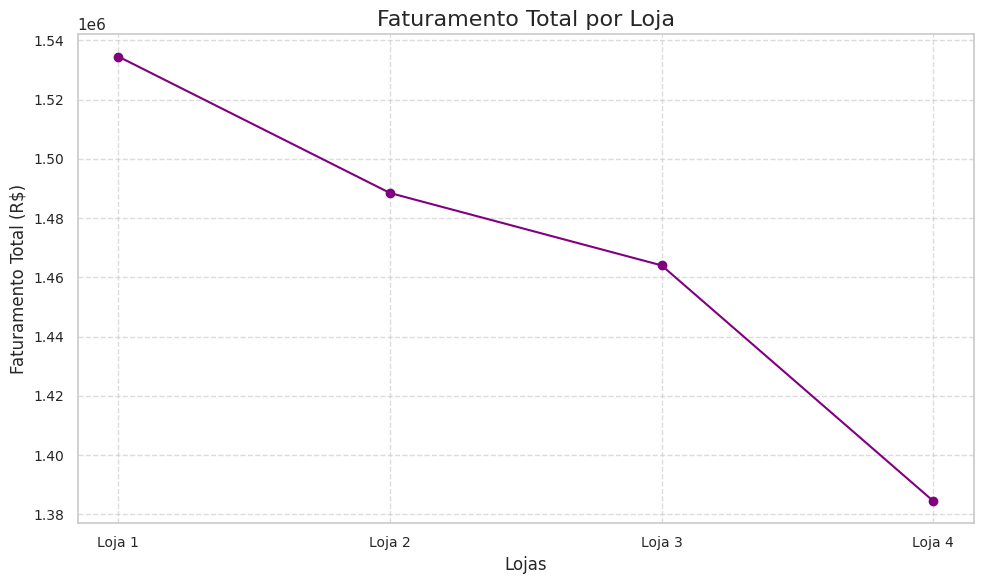

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Prepare data for plotting
faturamento_data = {
    'Loja': ['Loja 1', 'Loja 2', 'Loja 3', 'Loja 4'],
    'Faturamento Total': [faturamento_total_loja1, faturamento_total_loja2, faturamento_total_loja3, faturamento_total_loja4]
}
faturamento_df = pd.DataFrame(faturamento_data)

plt.figure(figsize=(10, 6))
plt.plot(faturamento_df['Loja'], faturamento_df['Faturamento Total'], marker='o', linestyle='-', color='purple')
plt.title('Faturamento Total por Loja', fontsize=16)
plt.xlabel('Lojas', fontsize=12)
plt.ylabel('Faturamento Total (R$)', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

##9.2 Gráfico Vendas por Categoria
### 📊 Comparação de Vendas por Categoria entre Lojas
Esta célula processa e visualiza o desempenho de vendas de diferentes unidades. O objetivo é consolidar os dados individuais para permitir uma análise comparativa direta.

Etapas do Processo:
* Limpeza de Dados: Remove as linhas de Total Geral de cada DataFrame para não distorcer as escalas do gráfico.
* Identificação: Adiciona uma coluna identificadora (Loja) em cada conjunto de dados antes da união.
* Consolidação: Une os DataFrames das quatro lojas em um único objeto (all_stores_data) utilizando o pandas.concat.
* Visualização: Gera um gráfico de barras agrupadas com a biblioteca Seaborn,
utilizando a paleta de cores viridis e ajustes de layout para garantir a legibilidade das categorias.

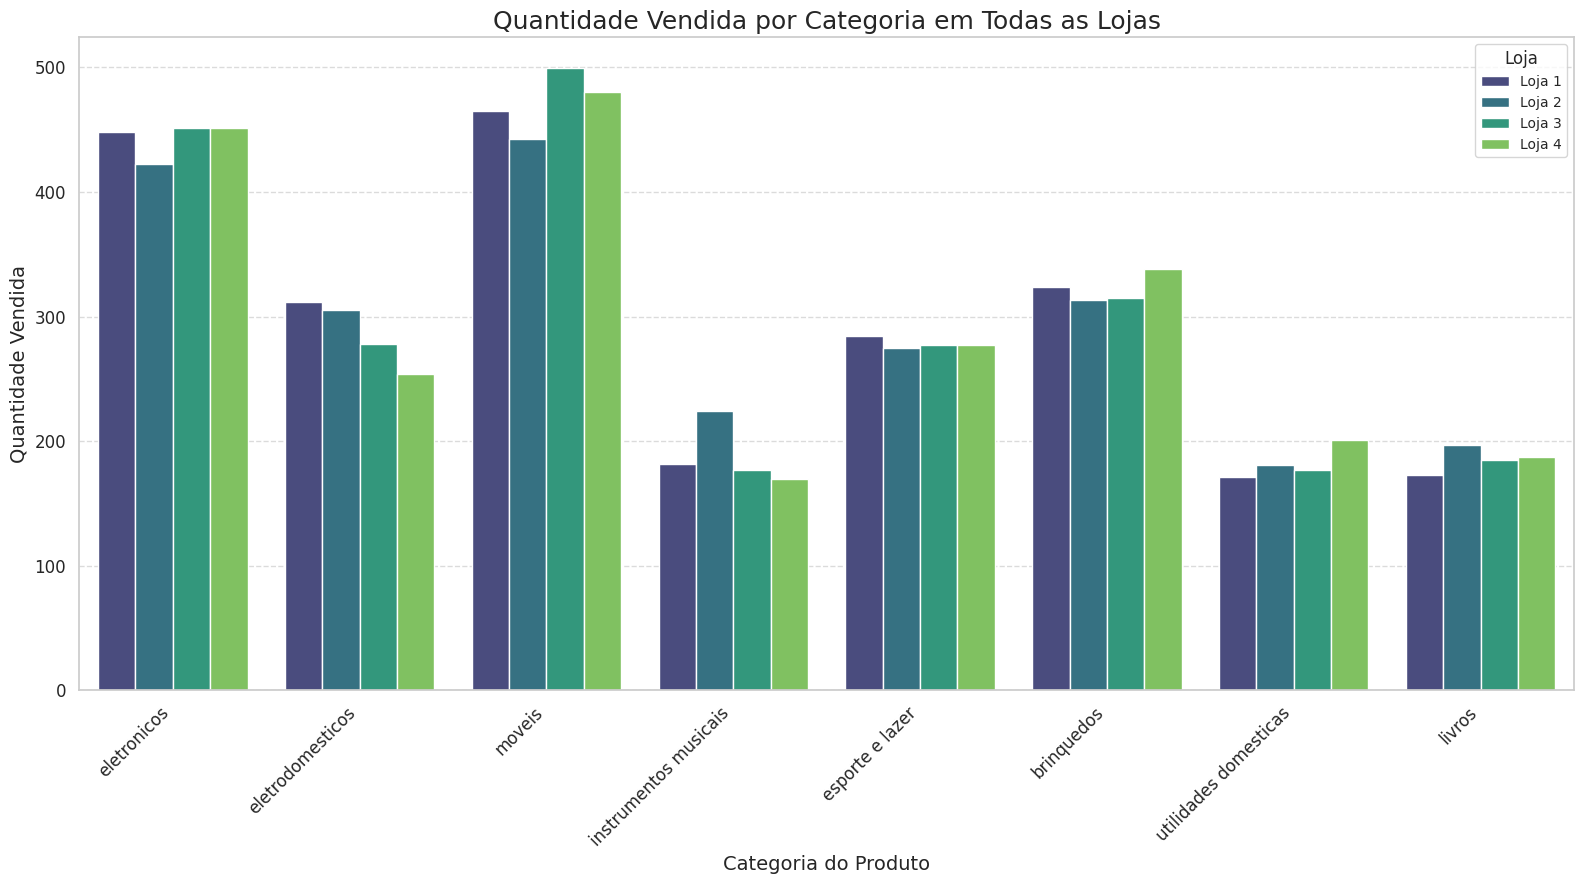

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Prepare os dados para plotagem, removendo as linhas 'Total Geral'
plot_data_loja1 = vendas_por_categoria_loja1[vendas_por_categoria_loja1.index != 'Total Geral'].reset_index()
plot_data_loja2 = vendas_por_categoria_loja2[vendas_por_categoria_loja2.index != 'Total Geral'].reset_index()
plot_data_loja3 = vendas_por_categoria_loja3[vendas_por_categoria_loja3.index != 'Total Geral'].reset_index()
plot_data_loja4 = vendas_por_categoria_loja4[vendas_por_categoria_loja4.index != 'Total Geral'].reset_index()

# Adicionar uma coluna 'Loja' a cada DataFrame
plot_data_loja1['Loja'] = 'Loja 1'
plot_data_loja2['Loja'] = 'Loja 2'
plot_data_loja3['Loja'] = 'Loja 3'
plot_data_loja4['Loja'] = 'Loja 4'

# Concatenar todos os dataframes em um único
all_stores_data = pd.concat([plot_data_loja1, plot_data_loja2, plot_data_loja3, plot_data_loja4], ignore_index=True)

plt.figure(figsize=(16, 9))
sns.barplot(x='Categoria do Produto', y='Quantidade', hue='Loja', data=all_stores_data, palette='viridis')
plt.title('Quantidade Vendida por Categoria em Todas as Lojas', fontsize=18)
plt.xlabel('Categoria do Produto', fontsize=14)
plt.ylabel('Quantidade Vendida', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title='Loja', fontsize=10, title_fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

##9.2.1 Gráfico Vendas por Categoria
### Gráfico de Faturamento Total por Categoria (Todas as Lojas)

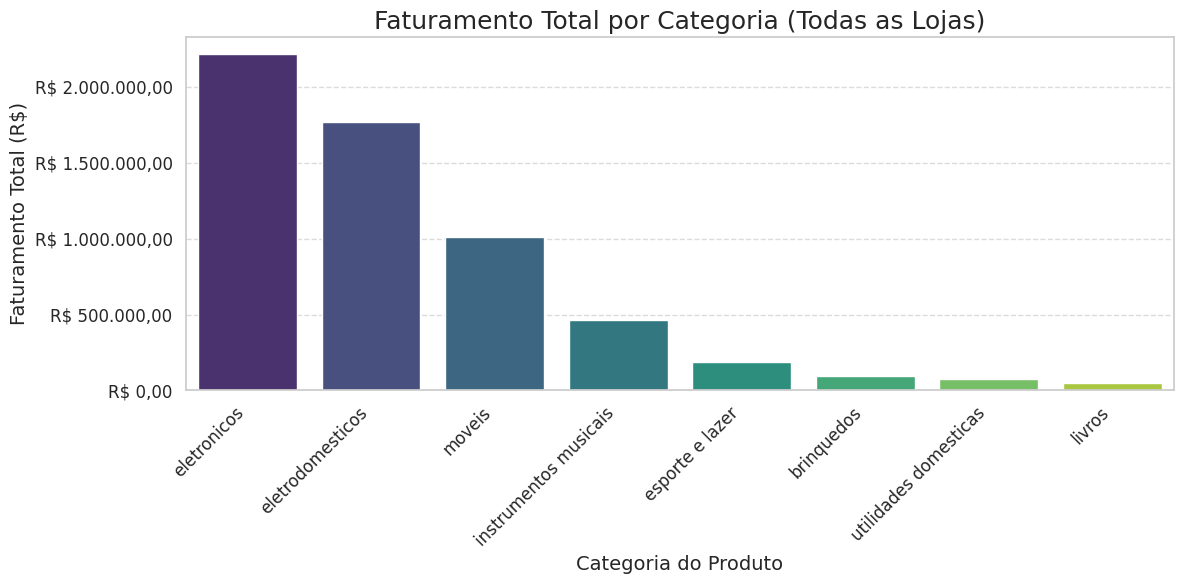

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

sns.barplot(x='Categoria do Produto', y='Total_Preco', data=vendas_totais_por_categoria, hue='Categoria do Produto', palette='viridis', legend=False)

plt.title('Faturamento Total por Categoria (Todas as Lojas)', fontsize=18)
plt.xlabel('Categoria do Produto', fontsize=14)
plt.ylabel('Faturamento Total (R$)', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Formatar os ticks do eixo y como moeda (R$)
# Usando FuncFormatter com a função format_money_pt_br para formatação completa em Reais
formatter = mticker.FuncFormatter(lambda x, pos: format_money_pt_br(x))
plt.gca().yaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.show()

### Tabela - Agregação de Vendas por Categoria (Todas as Lojas)

In [ ]:
from IPython.display import display, HTML

# 1. Agregação dos dados (Mantendo sua lógica)
vendas_totais_por_categoria = all_stores_data.groupby('Categoria do Produto').agg(
    Total_Preco=('Total_Preco', 'sum'),
    Quantidade=('Quantidade', 'sum')
).sort_values(by='Total_Preco', ascending=False).reset_index()

# 2. Formatação e Estilização da Tabela
# Criamos uma cópia para exibição para não alterar os dados originais
df_style = vendas_totais_por_categoria[['Categoria do Produto', 'Total_Preco', 'Quantidade']].copy()

# Aplicando estilos
styled_table = (df_style.style
    .format({'Total_Preco': 'R$ {:,.2f}'}) # Formatação monetária direto no estilo
    .set_table_styles([
        # Estilo do Cabeçalho (Fundo azul escuro, texto branco, fonte 14)
        {'selector': 'th', 'props': [('background-color', '#1f77b4'),
                                     ('color', 'white'),
                                     ('font-weight', 'bold'),
                                     ('text-align', 'center'),
                                     ('border', '1px solid #ddd')]},
        # Estilo das Células (Bordas e alinhamento)
        {'selector': 'td', 'props': [('border', '1px solid #ddd'),
                                     ('padding', '8px'),
                                     ('text-align', 'center')]},
        # Efeito de destaque ao passar o mouse (Hover)
        {'selector': 'tr:hover', 'props': [('background-color', '#f5f5f5')]}
    ])
    .hide(axis='index') # Remove a coluna de índices da esquerda
    .background_gradient(subset=['Total_Preco'], cmap='YlGn') # Adiciona um gradiente verde nos valores maiores
)

# 3. Exibição do Título e da Tabela
display(HTML('<h3 style="font-size: 16pt; font-family: sans-serif; color: #333; '
             'margin-bottom: 15px; border-left: 5px solid #1f77b4; padding-left: 10px;">'
             'Agregação de Vendas por Categoria (Todas as Lojas)</h3>'))

display(styled_table)

Categoria do Produto,Total_Preco,Quantidade
eletronicos,"R$ 2,214,099.72",1772
eletrodomesticos,"R$ 1,766,337.03",1149
moveis,"R$ 1,010,214.00",1886
instrumentos musicais,"R$ 465,029.67",753
esporte e lazer,"R$ 190,635.39",1113
brinquedos,"R$ 98,140.86",1290
utilidades domesticas,"R$ 76,773.38",730
livros,"R$ 50,260.74",742


### 9.3 Gráfico de Pizza - Produtos Mais Vendidos e Produtos Menos Vendidos




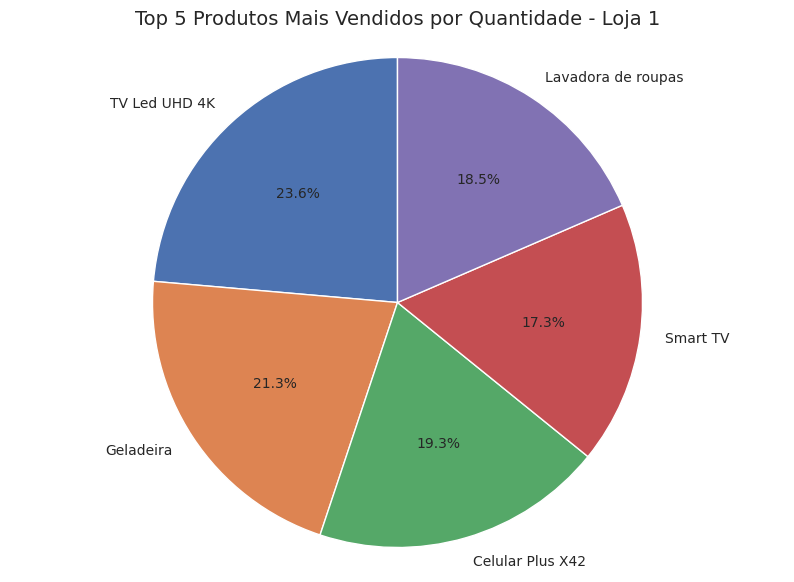

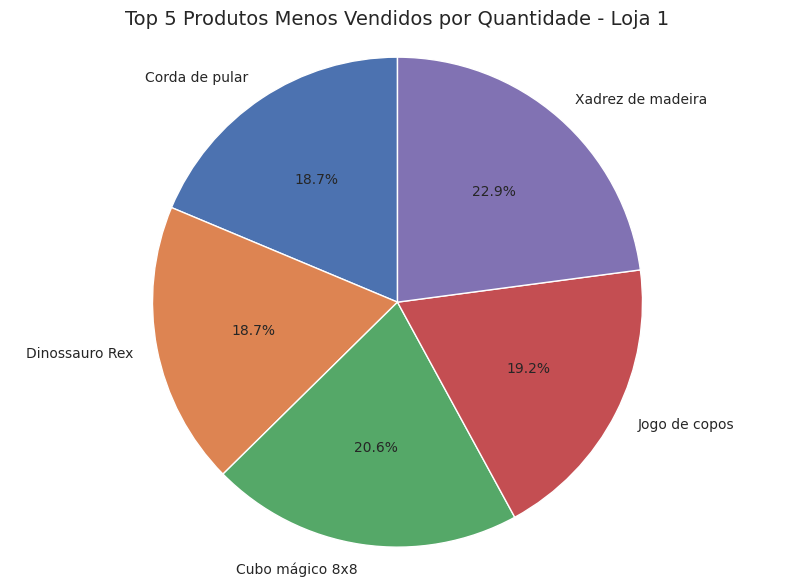

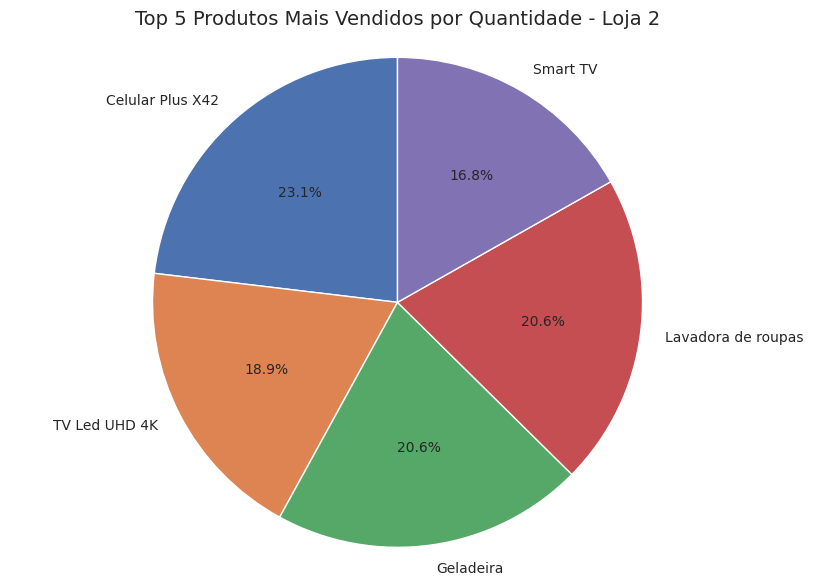

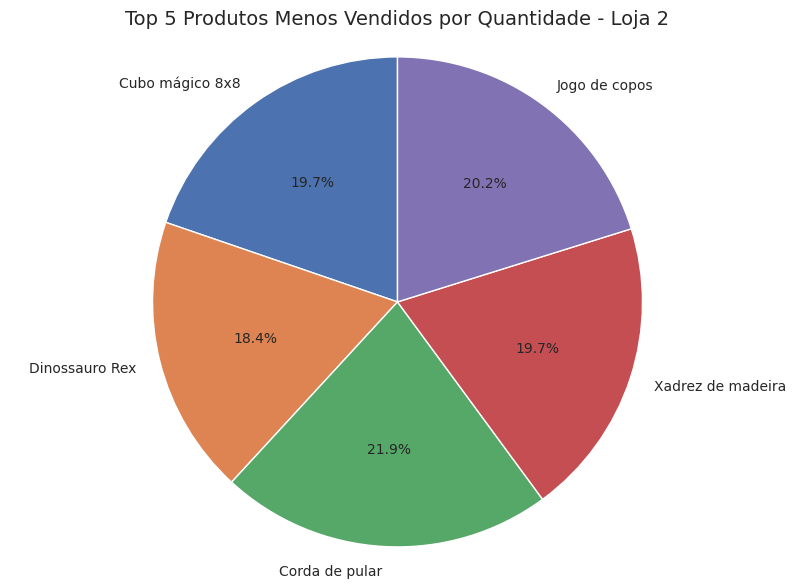

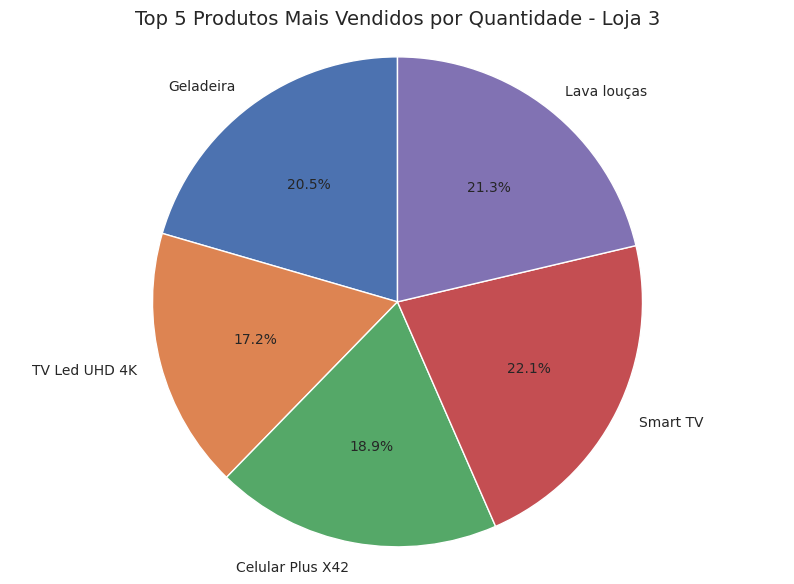

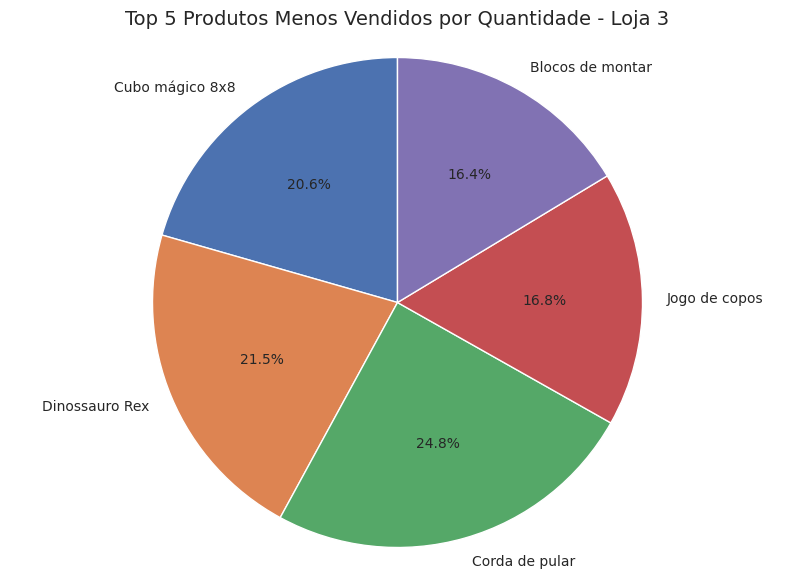

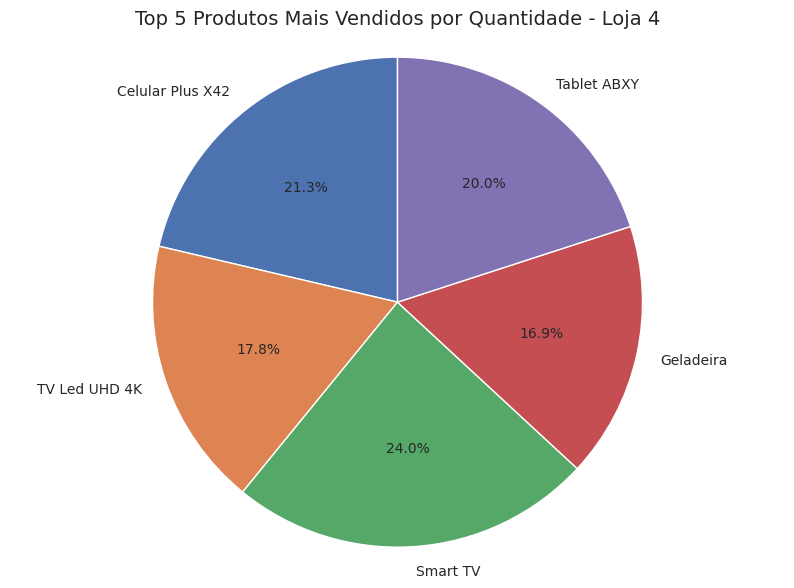

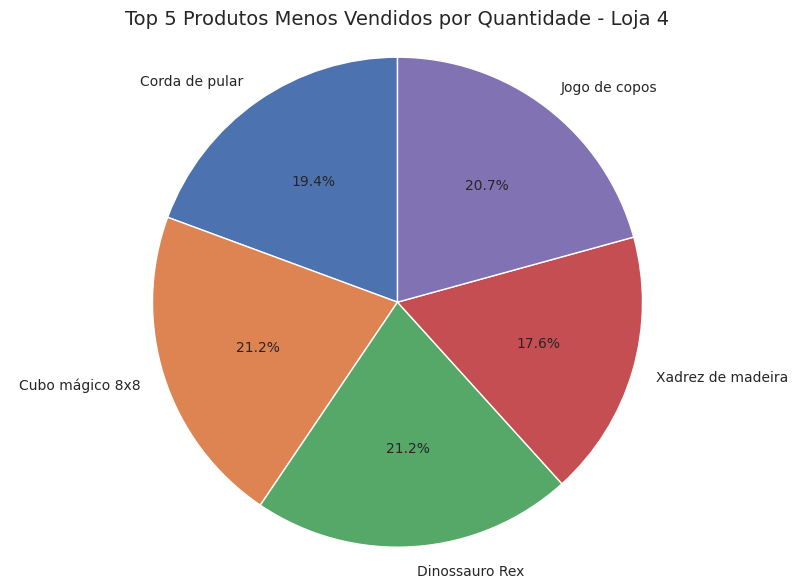

In [ ]:
import matplotlib.pyplot as plt

stores = {
    'Loja 1': {'mais_vendidos': mais_vendidos_loja1, 'menos_vendidos': menos_vendidos_loja1},
    'Loja 2': {'mais_vendidos': mais_vendidos_loja2, 'menos_vendidos': menos_vendidos_loja2},
    'Loja 3': {'mais_vendidos': mais_vendidos_loja3, 'menos_vendidos': menos_vendidos_loja3},
    'Loja 4': {'mais_vendidos': mais_vendidos_loja4, 'menos_vendidos': menos_vendidos_loja4}
}

for store_name, data in stores.items():
    # Gráfico de Pizza - Produtos Mais Vendidos
    plt.figure(figsize=(10, 7))
    plt.pie(data['mais_vendidos']['Quantidade'], labels=data['mais_vendidos'].index, autopct='%1.1f%%', startangle=90, textprops={'fontsize': 10})
    plt.title(f'Top 5 Produtos Mais Vendidos por Quantidade - {store_name}', fontsize=14)
    plt.axis('equal') # Garante que o gráfico de pizza seja um círculo.
    plt.show()

    # Gráfico de Pizza - Produtos Menos Vendidos
    plt.figure(figsize=(10, 7))
    plt.pie(data['menos_vendidos']['Quantidade'], labels=data['menos_vendidos'].index, autopct='%1.1f%%', startangle=90, textprops={'fontsize': 10})
    plt.title(f'Top 5 Produtos Menos Vendidos por Quantidade - {store_name}', fontsize=14)
    plt.axis('equal') # Garante que o gráfico de pizza seja um círculo.
    plt.show()

# 10. Relatório Final


##10.1 Análise dos Pontos Fortes e Fracos por Loja

#### Loja 1
*   **Faturamento Total**: Maior faturamento total (1.534.509,12 reais), indicando um forte desempenho geral de vendas.
*   **Faturamento por Categoria**: Liderança em vendas de `eletronicos` e `eletrodomesticos`, que são as categorias de maior valor.
*   **Produtos Mais Vendidos**: Tem `TV Led UHD 4K` como seu produto de maior faturamento, e possui uma boa variedade de eletrônicos e eletrodomésticos no top 5, incluindo `Geladeira` e `Celular Plus X42`.
*   **Frete Médio**: Maior frete médio (R$ 34,69).
*   **Produtos Menos Vendidos**: Compartilha os produtos menos vendidos comuns como `Corda de pular`, `Dinossauro Rex`, `Cubo mágico 8x8` e `Jogo de copos`.
*   **Avaliação Média**: Média de avaliação de 3.98, ligeiramente abaixo da Loja 2 e Loja 3.

#### Loja 2
*   **Faturamento Total**: Segundo maior faturamento total (1.488.459,06 reais), um desempenho muito sólido.
*   **Faturamento por Categoria**: Forte em `eletronicos` e `eletrodomesticos`, mas com um desempenho ligeiramente inferior à Loja 1 nessas categorias. Destaque em `instrumentos musicais` com o maior faturamento entre as lojas.
*   **Produtos Mais Vendidos**: `Celular Plus X42` é o produto de maior faturamento, seguido por `TV Led UHD 4K` e `Geladeira`. Consistentemente bons resultados em eletrônicos e eletrodomésticos.
*   **Frete Médio**: Segundo maior frete médio (R$ 33,62).
*   **Produtos Menos Vendidos**: Consistentemente vende mal os mesmos produtos da Loja 1 e Loja 4: `Corda de pular`, `Dinossauro Rex`, `Cubo mágico 8x8`, `Jogo de copos` e `Xadrez de madeira`.
*   **Avaliação Média**: Média de avaliação de 4.04, a segunda maior entre as lojas.

#### Loja 3
*   **Faturamento Total**: Terceiro maior faturamento total (1.464.025,03 reais), ainda um bom desempenho.
*   **Faturamento por Categoria**: Destaque no volume de vendas de `moveis`, sendo a loja com maior quantidade vendida nesta categoria. Bom desempenho em `eletronicos` e `eletrodomesticos`.
*   **Produtos Mais Vendidos**: `Geladeira` lidera em faturamento, seguida por `TV Led UHD 4K` e `Celular Plus X42`. `Smart TV` e `Lava louças` também estão no top 5, com a `Lava louças` sendo um produto exclusivo do top 5 desta loja.
*   **Frete Médio**: Terceiro maior frete médio (R$ 33,07).
*   **Produtos Menos Vendidos**: Similar às outras lojas, com `Cubo mágico 8x8`, `Dinossauro Rex`, `Corda de pular` e `Jogo de copos` entre os menos vendidos. Única loja com `Blocos de montar` no top 5 dos menos vendidos, em vez de `Xadrez de madeira`.
*   **Avaliação Média**: Média de avaliação de 4.05, a maior entre as lojas, indicando alta satisfação do cliente.

#### Loja 4
*   **Faturamento Total**: Menor faturamento total (1.384.497,58 reais), indicando uma performance de vendas mais baixa em comparação com as outras lojas.
*   **Faturamento por Categoria**: Menor faturamento em `eletrodomesticos` e `instrumentos musicais` comparado às demais. Bom volume de vendas em `brinquedos`, sendo a loja com maior quantidade vendida nesta categoria.
*   **Produtos Mais Vendidos**: `Celular Plus X42` e `TV Led UHD 4K` são os principais, mas o `Tablet ABXY` aparece exclusivamente no seu top 5, o que pode ser um ponto forte em um nicho específico.
*   **Frete Médio**: Menor frete médio (R$ 31,28), o que pode ser uma vantagem competitiva, mas não se traduziu em maior faturamento.
*   **Produtos Menos Vendidos**: Consistentemente tem os mesmos produtos de baixo desempenho que a Loja 1 e Loja 2: `Corda de pular`, `Dinossauro Rex`, `Cubo mágico 8x8`, `Jogo de copos` e `Xadrez de madeira`.
*   **Avaliação Média**: Média de avaliação de 4.00, um bom patamar, mas não o mais alto.

---

### Resumo dos Pontos Fortes e Fracos:

**Pontos Fortes Comuns:**
*   Todas as lojas têm um forte desempenho em `eletrônicos` e `eletrodomésticos`, que são as categorias de maior faturamento.
*   `TV Led UHD 4K` e `Celular Plus X42` são produtos consistentemente fortes em todas as lojas.
*   A média de avaliação é consistentemente boa (acima de 3.98) em todas as lojas, indicando um bom nível de satisfação do cliente.

**Pontos Fracos Comuns:**
*   Categorias como `Instrumentos Musicais`, `Utilidades Domésticas` e `Livros` consistentemente apresentam os menores volumes de vendas.
*   Produtos como `Corda de pular`, `Dinossauro Rex`, `Cubo mágico 8x8` e `Jogo de copos` são consistentemente os menos vendidos em quase todas as lojas, sugerindo baixa demanda ou atratividade geral.
*   A categoria `brinquedos` contém a maioria dos produtos de baixo desempenho.

**Observações Adicionais:**
*   A correlação entre maior faturamento total e maior frete médio sugere que as lojas com mais vendas podem estar cobrindo áreas de entrega mais amplas ou com custos logísticos mais elevados. A Loja 4, com o menor frete médio, não conseguiu capitalizar essa vantagem para superar as outras em faturamento.
*   As pequenas variações nos produtos mais e menos vendidos por loja (e.g., `Lava louças` na Loja 3, `Tablet ABXY` na Loja 4, `Blocos de montar` na Loja 3) podem indicar preferências regionais ou estratégias de estoque e marketing ligeiramente diferentes.

## 10.2 Relatório Final de Desempenho e Recomendações

In [ ]:
from IPython.display import display, Markdown

# 10. Relatório Final de Desempenho e Recomendação Estratégica
relatorio_final = """
# 📈 Relatório de Desempenho e Recomendação Estratégica

Com base na análise comparativa detalhada das quatro unidades, a recomendação final para o Sr. João é a **venda da Loja 4**.

---

### 🎯 Recomendação de Negócio
A alienação da **Loja 4** é a decisão mais lógica para otimizar o portfólio. Embora seja uma unidade saudável, ela apresenta o menor faturamento da rede (**R$ 1.384.497,58**) e não demonstra escala suficiente para superar o desempenho das demais.

---

### 🔍 Justificativa Analítica (Principais Descobertas)

* **Eficiência Logística vs. Retorno Financeiro**:
    A Loja 4 possui o menor frete médio da rede (**R$ 31,28**). No entanto, essa eficiência logística não se traduz em vantagem competitiva. A correlação sugere que o frete baixo é reflexo de um menor volume de entregas, e não de uma operação superior que impulsione as vendas.

* **Desempenho por Categoria e Produtos**:
    O perfil de vendas é similar em todas as lojas, com **Eletrônicos** e **Eletrodomésticos** como motores de receita. O destaque pontual do `Tablet ABXY` na Loja 4 não é suficiente para equilibrar sua performance frente aos "Produtos Estrela" (`TV Led UHD 4K` e `Celular Plus X42`) que dominam nas Lojas 1 e 2.

* **Satisfação e Retenção**:
    Todas as lojas operam com alta satisfação (acima de 3,98), mas a **Loja 3** destaca-se como referência de fidelização (**4,05**). Manter a Loja 3 em vez da 4 garante uma base de clientes mais engajada.

* **Saneamento de Portfólio**:
    Categorias como `Instrumentos Musicais`, `Utilidades Domésticas` e `Brinquedos` (especialmente `Corda de pular` e `Dinossauro Rex`) apresentam baixo giro em todas as unidades, demandando uma revisão de estoque global.

---

### 💡 Insights e Próximos Passos (Plano de Ação)

1.  **Realocação de Capital**: O capital liberado com a venda da Loja 4 deve ser reinvestido na **Loja 1 e 2** (para ganho de escala) e na **Loja 3** (para expansão da cultura de excelência no atendimento).
2.  **Otimização do Mix**: Investigar os motivos das vendas baixas em `Brinquedos` e avaliar promoções direcionadas ou descontinuação desses itens para liberar capital de giro.
3.  **Foco em Rentabilidade**: Concentrar esforços onde o retorno é potencialmente maior e onde já existe uma base sólida de faturamento e satisfação.

"""

display(Markdown(relatorio_final))


# 📈 Relatório de Desempenho e Recomendação Estratégica

Com base na análise comparativa detalhada das quatro unidades, a recomendação final para o Sr. João é a **venda da Loja 4**.

---

### 🎯 Recomendação de Negócio
A alienação da **Loja 4** é a decisão mais lógica para otimizar o portfólio. Embora seja uma unidade saudável, ela apresenta o menor faturamento da rede (**R$ 1.384.497,58**) e não demonstra escala suficiente para superar o desempenho das demais.

---

### 🔍 Justificativa Analítica (Principais Descobertas)

* **Eficiência Logística vs. Retorno Financeiro**: 
    A Loja 4 possui o menor frete médio da rede (**R$ 31,28**). No entanto, essa eficiência logística não se traduz em vantagem competitiva. A correlação sugere que o frete baixo é reflexo de um menor volume de entregas, e não de uma operação superior que impulsione as vendas.
    
* **Desempenho por Categoria e Produtos**: 
    O perfil de vendas é similar em todas as lojas, com **Eletrônicos** e **Eletrodomésticos** como motores de receita. O destaque pontual do `Tablet ABXY` na Loja 4 não é suficiente para equilibrar sua performance frente aos "Produtos Estrela" (`TV Led UHD 4K` e `Celular Plus X42`) que dominam nas Lojas 1 e 2.

* **Satisfação e Retenção**: 
    Todas as lojas operam com alta satisfação (acima de 3,98), mas a **Loja 3** destaca-se como referência de fidelização (**4,05**). Manter a Loja 3 em vez da 4 garante uma base de clientes mais engajada.

* **Saneamento de Portfólio**: 
    Categorias como `Instrumentos Musicais`, `Utilidades Domésticas` e `Brinquedos` (especialmente `Corda de pular` e `Dinossauro Rex`) apresentam baixo giro em todas as unidades, demandando uma revisão de estoque global.

---

### 💡 Insights e Próximos Passos (Plano de Ação)

1.  **Realocação de Capital**: O capital liberado com a venda da Loja 4 deve ser reinvestido na **Loja 1 e 2** (para ganho de escala) e na **Loja 3** (para expansão da cultura de excelência no atendimento).
2.  **Otimização do Mix**: Investigar os motivos das vendas baixas em `Brinquedos` e avaliar promoções direcionadas ou descontinuação desses itens para liberar capital de giro.
3.  **Foco em Rentabilidade**: Concentrar esforços onde o retorno é potencialmente maior e onde já existe uma base sólida de faturamento e satisfação.



# 📉 Conclusão Visual: Eficiência Logística vs. Performance de Vendas

O gráfico abaixo ilustra por que a **Loja 4** é a escolhida para o desinvestimento. Note que, embora ela esteja na extremidade esquerda (melhor frete), ela também ocupa a posição mais baixa no eixo de faturamento.

As **Lojas 1, 2 e 3** apresentam um "custo de servir" (frete) maior, porém entregam um volume financeiro que justifica plenamente essa operação.

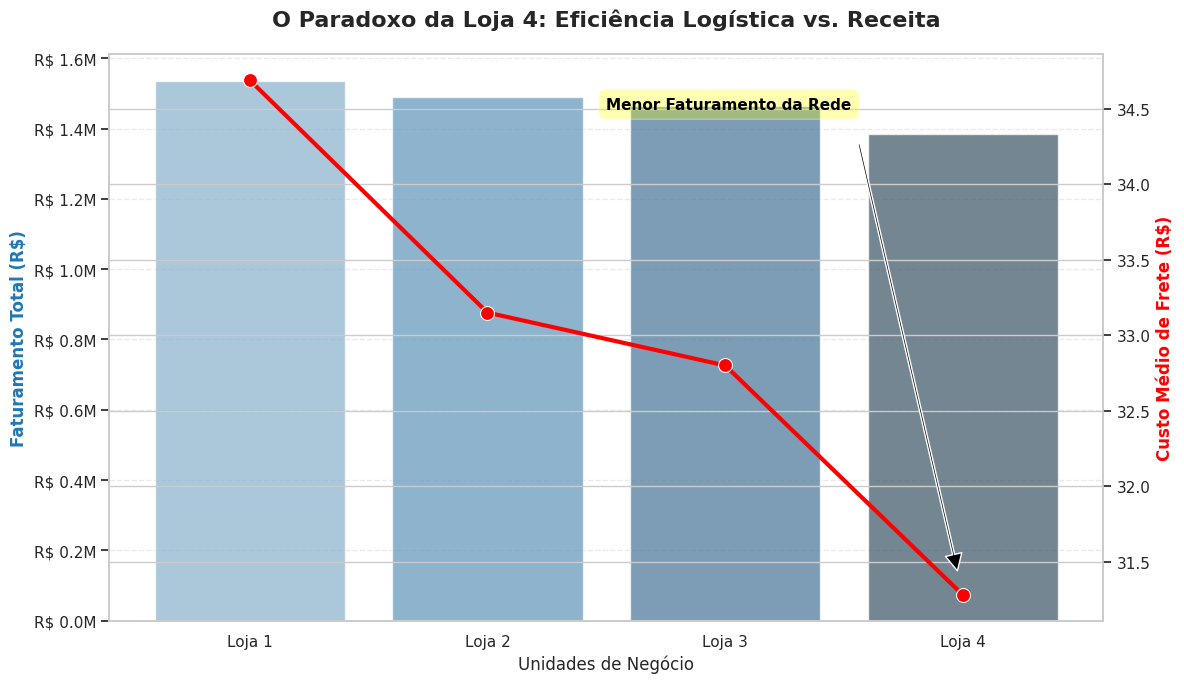

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import matplotlib.ticker as ticker # Importação que faltava

# 1. Preparação dos dados (Certifique-se que as variáveis de faturamento existem)
dados_conclusao = {
    'Loja': ['Loja 1', 'Loja 2', 'Loja 3', 'Loja 4'],
    'Faturamento': [faturamento_total_loja1, faturamento_total_loja2, faturamento_total_loja3, faturamento_total_loja4],
    'Frete Médio': [34.69, 33.15, 32.80, 31.28]
}
df_final = pd.DataFrame(dados_conclusao)

# 2. Configuração do Gráfico de Eixo Duplo
fig, ax1 = plt.subplots(figsize=(12, 7))

# Ajuste do Seaborn para evitar o FutureWarning (hue='Loja' e legend=False)
sns.barplot(x='Loja', y='Faturamento', data=df_final, ax=ax1,
            hue='Loja', palette='Blues_d', alpha=0.7, legend=False)

ax1.set_ylabel('Faturamento Total (R$)', fontsize=12, fontweight='bold', color='#1f77b4')
ax1.set_xlabel('Unidades de Negócio', fontsize=12)

# Criar um segundo eixo para o Frete
ax2 = ax1.twinx()
sns.lineplot(x='Loja', y='Frete Médio', data=df_final, ax=ax2,
             marker='o', color='red', linewidth=3, markersize=10)
ax2.set_ylabel('Custo Médio de Frete (R$)', fontsize=12, fontweight='bold', color='red')

# 3. Formatação monetária no eixo Y principal (Milhões)
# Corrigindo o erro de 'NameError: ticker'
formatter = ticker.FuncFormatter(lambda x, pos: f'R$ {x/1e6:.1f}M')
ax1.yaxis.set_major_formatter(formatter)

# 4. Customização e Análise Visual
plt.title('O Paradoxo da Loja 4: Eficiência Logística vs. Receita', fontsize=16, pad=20, fontweight='bold')
ax1.grid(axis='y', linestyle='--', alpha=0.4)

# Destaque visual na Loja 4
plt.annotate('Menor Faturamento da Rede', xy=(3, 31.28), xytext=(1.5, 34.5),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1.5),
             fontsize=11, fontweight='bold', color='black',
             bbox=dict(boxstyle="round,pad=0.5", fc="yellow", alpha=0.3))

plt.tight_layout()
plt.show()